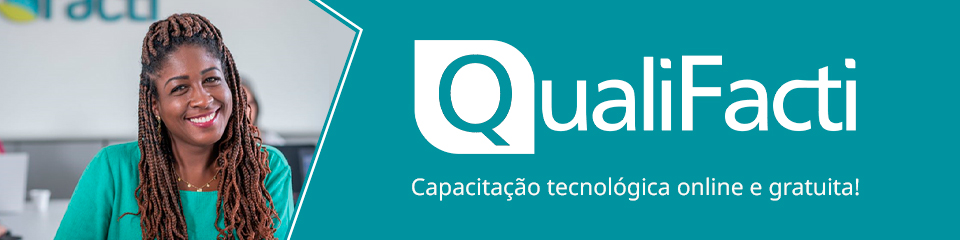

# **Inteligência Artificial aplicada à Visão Computacional**

**Capítulo 8: Visão Computacional aplicada ao reconhecimento de texto**



<p align="justify">

Todos os direitos reservados à Facti, 2024
<p>

[www.qualifacti.com.br](https://)

---

<p align="justify">
É importante esclarecer que estas atividades não compõem a avaliação e não haverá correção formal por parte dos instrutores; o objetivo é a autoaprendizagem e prática.
<p>

---

# **ETAPA CONSOLIDAR**

---

# **Recado importante**


Olá,
<p align="justify">
Como parte do capítulo de <b>reconhecimento de texto</b>, gostaríamos de ressaltar a importância de realizar as atividades de implementação fornecidas. Estas atividades são cuidadosamente desenhadas para reforçar o conteúdo apresentado.
Lembre-se, a implementação é uma habilidade que se aprimora com a prática. Ao aplicar os conceitos aprendidos, especialmente por meio da escrita e execução de códigos, você ganhará uma compreensão mais profunda e prática dos modelos.
Encorajamos todos a dedicar tempo a essas atividades. Ao fazer isso, você não apenas reforçará o que foi ensinado, mas também desenvolverá as habilidades essenciais de resolução de problemas e depuração de código.

Lembrem-se: não basta apenas aprender, é preciso codificar! O caminho para dominar os modelos começa com a experiência prática.

Atenciosamente,

Júlio e Marcelo
<p>

---

# **Estudo de caso**

## Importando as bibliotecas

In [ ]:
import tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import zipfile
from tensorflow.keras.models import load_model
from imutils.contours import sort_contours
import imutils
from google.colab.patches import cv2_imshow

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## Carregando as bases de dados

**Conjunto MNIST 0-9**

In [ ]:
# Importa o conjunto de dados MNIST da biblioteca Keras.
# O MNIST é um conjunto de dados amplamente utilizado que contém 70.000 imagens de dígitos escritos à mão (0-9),
# dividido em 60.000 imagens para treinamento e 10.000 para teste. Cada imagem tem a resolução de 28x28 pixels em escala de cinza.
from tensorflow.keras.datasets import mnist

In [ ]:
# Carrega o conjunto de dados MNIST, dividindo-o em dados de treinamento e teste.
# 'train_data' contém 60.000 imagens de treino e 'train_labels' os rótulos correspondentes (dígitos de 0 a 9).
# 'test_data' contém 10.000 imagens de teste e 'test_labels' os rótulos correspondentes.
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

In [ ]:
# Verifica as dimensões dos conjuntos de dados de treinamento e teste.
train_data.shape, test_data.shape

In [ ]:
# Combina os dados de treinamento e teste em um único conjunto de dados.
# 'np.vstack' empilha verticalmente os arrays de 'train_data' e 'test_data' para formar um único array de 70.000 imagens.
# 'np.hstack' empilha horizontalmente os arrays de rótulos 'train_labels' e 'test_labels' para formar um único array de rótulos correspondente.
digitos_data = np.vstack([train_data, test_data])
digitos_labels = np.hstack([train_labels, test_labels])

In [ ]:
# Gera um número inteiro aleatório entre 0 e o número total de amostras no conjunto de dados 'digitos_data'.
np.random.randint(0, digitos_data.shape[0])

In [ ]:
# Seleciona um índice aleatório para escolher uma imagem e seu rótulo correspondente a partir do conjunto de dados 'digitos_data'.
indice = np.random.randint(0, digitos_data.shape[0])
# Exibe a imagem correspondente ao índice aleatório selecionado usando Matplotlib.
plt.imshow(digitos_data[indice], cmap='gray')
# Define o título da imagem com base na classe (rótulo) correspondente.
plt.title('Classe: ' + str(digitos_labels[indice]));

# Conectando com o Drive e acessando os arquivos

In [ ]:
# Conectando o Colab ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Realize o dowload da pasta Material_complementar_reconhecimento_texto.zip do Google Sala de Aula e transira-a para o seu Google Drive
# Localize o caminho da pasta no menu Arquivos, no menu lateral esquerdo
path = "/content/drive/MyDrive/Material_complementar_reconhecimento_texto.zip"
zip_object = zipfile.ZipFile(file=path, mode="r")
zip_object.extractall("./")

**Conjunto Kaggle A-Z**

In [ ]:
# Cria um objeto 'zip_object' para abrir o arquivo zip especificado.
zip_object = zipfile.ZipFile(file='/content/drive/MyDrive/alfabeto_A-Z.zip', mode = 'r')
# Extrai todos os arquivos do arquivo zip para o diretório atual ('./').
zip_object.extractall('./')
# Fecha o arquivo zip após a extração, liberando recursos.
zip_object.close()

In [ ]:
# Carrega o conjunto de dados do arquivo CSV contendo dados de letras manuscritas A-Z.
dataset_az = pd.read_csv('/content/A_Z Handwritten Data/A_Z Handwritten Data.csv').astype('float32')

In [ ]:
# Remove a coluna de rótulos ('0') do conjunto de dados 'dataset_az' para obter apenas os dados de imagem.
# A coluna '0' do conjunto de dados contém os rótulos correspondentes a cada imagem de letra.
alfabeto_data = dataset_az.drop('0', axis = 1)
alfabeto_labels = dataset_az['0']

In [ ]:
# Redimensiona os dados das letras manuscritas em um formato de imagem de 28x28 pixels.
alfabeto_data = np.reshape(alfabeto_data.values, (alfabeto_data.shape[0], 28, 28))

In [ ]:
# Seleciona um índice aleatório para escolher uma imagem e seu rótulo correspondente a partir do conjunto de dados 'alfabeto_data'.
indice = np.random.randint(0, alfabeto_data.shape[0])
plt.imshow(alfabeto_data[indice], cmap = 'gray') # Exibe a imagem correspondente ao índice aleatório selecionado usando Matplotlib.
plt.title('Classe ' + str(alfabeto_labels[indice])); # Define o título da imagem com base na classe (rótulo) correspondente.

**Junção das bases de dados**

In [ ]:
# Exibe os rótulos do conjunto de dados 'digitos_labels' e os valores únicos presentes nesses rótulos.
digitos_labels, np.unique(digitos_labels)

In [ ]:
# Exibe os rótulos do conjunto de dados 'alfabeto_labels' e os valores únicos presentes nesses rótulos.
alfabeto_labels, np.unique(alfabeto_labels)

In [ ]:
# Adiciona o valor 10 a todos os rótulos no conjunto 'alfabeto_labels'.
alfabeto_labels += 10

In [ ]:
# Combina os dados de letras (alfabeto_data) e dígitos (digitos_data) em um único conjunto de dados.
data = np.vstack([alfabeto_data, digitos_data])
labels = np.hstack([alfabeto_labels, digitos_labels])

In [ ]:
# Converte o array 'data' para o tipo 'float32'.
data = np.array(data, dtype='float32')

In [ ]:
# Expande a dimensão do array 'data', adicionando uma nova dimensão no final (axis = -1).
data = np.expand_dims(data, axis = -1)

**Pré-processamento dos dados**

In [ ]:
# Verifica os valores mínimo e máximo dos pixels na primeira imagem do conjunto de dados 'data'.
data[0].min(), data[0].max()
data /= 255.0 # Normaliza os dados de imagem, dividindo todos os valores de pixel por 255.
np.unique(labels) # Verifica os rótulos únicos presentes no conjunto de dados 'labels', que combinam os rótulos de dígitos (0-9) e letras (10-35).

In [ ]:
# Cria um objeto 'LabelBinarizer', que será usado para converter os rótulos em um formato binário (one-hot encoding).
# O LabelBinarizer transforma os rótulos inteiros (0-9 para dígitos e 10-35 para letras) em vetores binários de classe, o que é necessário para classificação multicategórica em redes neurais.
le = LabelBinarizer()
labels = le.fit_transform(labels)

In [ ]:
# Exibe o rótulo one-hot encoded para o índice 30000 do array 'labels', o comprimento desse rótulo (número de classes), e o valor resultante de 26 (letras) + 10 (dígitos), que indica o total de classes possíveis no problema.
labels[30000], len(labels[30000]), 26 + 10
classes_total = labels.sum(axis=0)

In [ ]:
# Exibe a imagem no índice 30000 do conjunto de dados 'data' usando Matplotlib.
plt.imshow(data[30000].reshape(28,28), cmap='gray')
plt.title(str(labels[30000]));

In [ ]:
# Inicializa um dicionário vazio 'classes_peso' que será usado para armazenar os pesos de cada classe.
classes_peso = {}
# Itera sobre todas as classes (de 0 a len(classes_total)), onde 'classes_total' contém o número de exemplos em cada classe.
for i in range(0, len(classes_total)):
  # Calcula o peso de cada classe, dividindo o número máximo de exemplos em uma classe pela quantidade de exemplos da classe 'i'.
  classes_peso[i] = classes_total.max() / classes_total[i]

In [ ]:
# Divide os dados e os rótulos em conjuntos de treinamento e teste usando train_test_split.
# 'data' contém as imagens e 'labels' os rótulos one-hot encoded. O conjunto de teste terá 20% dos dados.
# 'stratify=labels' garante que a divisão dos dados mantenha a mesma proporção de classes nos conjuntos de treino e teste.
# 'random_state=1' garante que a divisão seja reproduzível (sempre a mesma divisão).
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state = 1)

In [ ]:
# Cria um objeto 'ImageDataGenerator' para realizar a augmentação (aumentação) de dados em imagens.
# A augmentação é usada para gerar variações artificiais nas imagens, ajudando o modelo a generalizar melhor e evitando overfitting.
# Os parâmetros configuram o tipo de transformações que serão aplicadas às imagens durante o treinamento.
from tensorflow.keras.preprocessing.image import ImageDataGenerator
augmentation = ImageDataGenerator(rotation_range=10, zoom_range=0.05, width_shift_range=0.1,
                                  height_shift_range=0.1, horizontal_flip = False)

**Criação da estrutura da rede neural**

In [ ]:
# Importa as classes necessárias da biblioteca Keras para criar e treinar um modelo de rede neural convolucional (CNN).
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint

# Inicializa um modelo de rede neural sequencial.
rede_neural = Sequential()

rede_neural.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
rede_neural.add(MaxPool2D(pool_size=(2,2)))

rede_neural.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
rede_neural.add(MaxPool2D(pool_size=(2,2)))

rede_neural.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='valid'))
rede_neural.add(MaxPool2D(pool_size=(2,2)))

rede_neural.add(Flatten())

rede_neural.add(Dense(64, activation='relu'))
rede_neural.add(Dense(128, activation='relu'))

rede_neural.add(Dense(36, activation='softmax'))

rede_neural.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

# Exibe um resumo detalhado da arquitetura da rede neural.
rede_neural.summary()

In [ ]:
# Define uma string contendo os nomes das classes, começando com os dígitos de 0 a 9.
nomes_labels = '0123456789'
# Adiciona as letras maiúsculas de A a Z à string, resultando em uma sequência de 36 caracteres.
nomes_labels += 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
# Converte a string de nomes de classes em uma lista, onde cada elemento será um único caractere (número ou letra).
nomes_labels = [l for l in nomes_labels]
print(nomes_labels)

**Treinamento da rede neural**

In [ ]:
# Define o nome do arquivo onde o modelo treinado será salvo.
arquivo_modelo = 'manuscrito.model.keras'
epochs = 10 # Define o número de épocas
batch_size = 128 # Define o tamanho do lote (batch size)

In [ ]:
# Cria um callback 'ModelCheckpoint' para salvar o modelo treinado com base na performance durante o treinamento.
checkpointer = ModelCheckpoint(arquivo_modelo, monitor='val_loss', verbose=1, save_best_only=True)

In [ ]:
# Calcula o número de iterações (steps) por época no treinamento com base no número total de exemplos no conjunto de treino 'X_train'
# e o tamanho do lote (batch_size). O operador '//' realiza a divisão inteira.len(X_train) // batch_size

In [ ]:
# Treinando a rede neural usando os dados de treinamento com augmentação de dados.
history = rede_neural.fit(augmentation.flow(X_train, y_train, batch_size=batch_size),
                                            validation_data = (X_test, y_test),
                                            steps_per_epoch = len(X_train) // batch_size,
                                            epochs = epochs,
                                            class_weight = classes_peso,
                                            verbose=1, callbacks=[checkpointer])

**Avaliação da rede neural**

In [ ]:
# Fazendo previsões no conjunto de teste 'X_test' usando o modelo treinado 'rede_neural'.
previsoes = rede_neural.predict(X_test, batch_size=batch_size)
len(previsoes[0]) # Exibe o número de classes (provavelmente 36, correspondendo a 10 dígitos + 26 letras) previstas para a primeira amostra no conjunto de previsões.


In [ ]:
# Retorna o índice da classe com a maior probabilidade para a primeira amostra do conjunto de previsões.
np.argmax(previsoes[0])

In [ ]:
# Avalia o desempenho do modelo treinado 'rede_neural' no conjunto de teste 'X_test' e 'y_test'.
rede_neural.evaluate(X_test, y_test)

In [ ]:
# Exibe um relatório de classificação detalhado usando o 'classification_report' do scikit-learn.
print(classification_report(y_test.argmax(axis=1), previsoes.argmax(axis=1), target_names=nomes_labels))

In [ ]:
# Exibe as chaves disponíveis no dicionário 'history.history', que armazena o histórico de métricas e perdas do treinamento.
history.history.keys()

In [ ]:
# Plota o gráfico da perda no conjunto de validação ('val_loss') ao longo das épocas de treinamento.
plt.plot(history.history['val_loss']);

In [ ]:
# Gera um gráfico da acurácia no conjunto de validação ao longo das épocas de treinamento.
plt.plot(history.history['val_accuracy']);

**Salvando o modelo no Google Drive**

In [ ]:
# Salva o modelo treinado 'rede_neural' em um arquivo com o formato '.keras'.
rede_neural.save('rede_neural.keras')

**Teste com imagens**

In [ ]:
# Importa a função 'load_model' da biblioteca Keras, que é usada para carregar um modelo previamente salvo.
from tensorflow.keras.models import load_model

In [ ]:
# Carrega o modelo salvo no arquivo 'rede_neural.keras' usando a função 'load_model'.
rede_neural_carregada = load_model('/content/rede_neural.keras')
rede_neural_carregada

In [ ]:
# Exibe um resumo detalhado do modelo carregado 'rede_neural_carregada'.
# O 'summary()' mostra informações sobre cada camada da rede, incluindo o tipo de camada, o formato de saída e o número de parâmetros treináveis por camada.
rede_neural_carregada.summary()

In [ ]:
# Importa o 'cv2_imshow' do Google Colab, que permite exibir imagens no notebook, uma vez que 'cv2.imshow' não funciona diretamente no Colab.
from google.colab.patches import cv2_imshow
img = cv2.imread('/content/imagens/letra-m.jpg')
cv2_imshow(img)

In [ ]:
# Converte a imagem 'img' de BGR (formato padrão do OpenCV) para escala de cinza usando 'cv2.cvtColor'.
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape
cv2_imshow(gray)

In [ ]:
# Aplica o limiar adaptativo (thresholding) Otsu à imagem em escala de cinza.
# O limiar binário inverso converte pixels com valores acima do limiar em preto (0) e abaixo do limiar em branco (255).
# Otsu é uma técnica que determina automaticamente o melhor valor de limiar para binarizar a imagem.
val, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
cv2_imshow(thresh)

In [ ]:
# Redimensiona a imagem binarizada (thresholded) para 28x28 pixels usando 'cv2.resize'.
img = cv2.resize(thresh, (28, 28))
cv2_imshow(img)

In [ ]:
# Converte os valores da imagem para o tipo float32 e normaliza os pixels, dividindo por 255.0.
img = img.astype('float32') / 255.0
img = np.expand_dims(img, axis = -1)
img = np.reshape(img, (1,28,28,1))

In [ ]:
# Usa o modelo carregado 'rede_neural_carregada' para fazer uma previsão com base na imagem preparada 'img'.
previsao = rede_neural_carregada.predict(img)

In [ ]:
# Retornando o índice da classe com a maior probabilidade no vetor de previsões 'previsao'.
np.argmax(previsao)

In [ ]:
# Retorna o nome da classe correspondente ao índice 22 na lista 'nomes_labels'.
nomes_labels[22]

# Carregando a rede neural

In [ ]:
# Carrega o modelo salvo no arquivo 'rede_neural.keras' usando a função 'load_model', restaurando o modelo completo.
rede_neural = load_model('/content/rede_neural.keras')
rede_neural.summary()

## Carregando a imagem de teste

In [ ]:
img = cv2.imread('/content/imagens/teste-manuscrito02.jpg') # Carrega a imagem localizada no diretório '/content/imagens/'
cv2_imshow(img)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Converte a imagem de BGR (padrão OpenCV) para escala de cinza
cv2_imshow(gray)

## Pré-processamento da imagem

In [ ]:
# Aplica o desfoque Gaussiano à imagem em escala de cinza 'gray'.
desfoque = cv2.GaussianBlur(gray, (3,3), 0)
cv2_imshow(desfoque)

In [ ]:
# Aplica o limiar adaptativo usando o método Gaussiano à imagem desfocada 'desfoque'.
adapt_media = cv2.adaptiveThreshold(desfoque, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 9)
cv2_imshow(adapt_media)

In [ ]:
# Inverte a imagem binarizada 'adapt_media', trocando pixels brancos (255) por pretos (0) e vice-versa.
inv = 255 - adapt_media
cv2_imshow(inv)

In [ ]:
# Aplica a operação de dilatação à imagem invertida 'inv'.
dilatado = cv2.dilate(inv, np.ones((3,3)))
cv2_imshow(dilatado)

In [ ]:
# Aplica o detector de bordas Canny à imagem desfocada 'desfoque'.
bordas = cv2.Canny(desfoque, 40, 150)
cv2_imshow(bordas)

In [ ]:
# Aplica a operação de dilatação à imagem de bordas 'bordas'.
dilatado = cv2.dilate(bordas, np.ones((3,3)))
cv2_imshow(dilatado)

## Detecção de contornos

In [ ]:
# Define uma função 'encontrar_contornos' para detectar contornos em uma imagem binarizada.
# Os contornos são as bordas dos objetos na imagem e podem ser usados para detectar e extrair regiões de interesse.
def encontrar_contornos(img):
  conts = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  conts = imutils.grab_contours(conts)
  conts = sort_contours(conts, method='left-to-right')[0]
  return conts

In [ ]:
# Faz uma cópia da imagem 'dilatado' e usa a função 'encontrar_contornos' para detectar os contornos na imagem dilatada.
conts = encontrar_contornos(dilatado.copy())

In [ ]:
# Define os valores mínimos e máximos para a largura (l_min, l_max) e altura (a_min, a_max) dos objetos que serão considerados na imagem.
# Esses valores são usados como critérios de filtragem para ignorar contornos que não atendem aos limites de tamanho especificados.
l_min, l_max = 4, 160
a_min, a_max = 14, 140

In [ ]:
# Inicializa a lista para armazenar os caracteres detectados.
caracteres = []
img_cp = img.copy() # Cria uma cópia da imagem original 'img' para desenhar retângulos ao redor dos caracteres detectados.
# Itera sobre os contornos detectados.
for c in conts:
  (x, y, w, h) = cv2.boundingRect(c) # Calcula a caixa delimitadora (bounding box) do contorno 'c', que retorna as coordenadas x, y e a largura (w) e altura (h) do contorno.
  # Verifica se a largura (w) e a altura (h) do contorno estão dentro dos limites definidos (l_min, l_max, a_min, a_max).
  # Apenas contornos dentro desses limites serão considerados como caracteres.
  if (w >= l_min and w <= l_max) and (h >= a_min and h <= a_max):
    roi = gray[y:y+ h, x:x + w] # Extrai a Região de Interesse (ROI) da imagem em escala de cinza 'gray' com base na caixa delimitadora (x, y, w, h).
    thresh = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1] # Aplica a binarização inversa com o método Otsu para a ROI, convertendo-a em uma imagem binária (preto e branco).
    cv2_imshow(thresh) # Exibe a ROI binarizada (o caractere isolado)
    cv2.rectangle(img_cp, (x, y), (x + w, y + h), (255, 100, 0), 2) # Desenha um retângulo ao redor do caractere detectado na cópia da imagem original 'img_cp'.
cv2_imshow(img_cp)

## Processando os caracteres detectados

## Extração ROI


In [ ]:
# Define uma função 'extra_roi' para extrair a Região de Interesse (ROI) de uma imagem.
def extra_roi(img):
  roi = img[y:y + h, x:x + w] # Extrai a região da imagem delimitada pelas coordenadas (x, y) e dimensões (w, h).
  return roi

## Limiarização

In [ ]:
# Define uma função 'limiarizacao' que aplica a binarização inversa com o método Otsu à imagem.
def limiarizacao(img):
  thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
  return thresh

## Redimensionamento

In [ ]:
# Define uma função 'redimensiona_img' para redimensionar a imagem mantendo a proporção e preenchendo com bordas pretas para ajustar ao tamanho 28x28.
def redimensiona_img(img, l, a):
  # Verifica se a largura (l) é maior que a altura (a). Se for, a imagem será redimensionada com a largura igual a 28 pixels.
  # Caso contrário, a imagem será redimensionada com a altura igual a 28 pixels, mantendo a proporção.
  if l > a:
    redimensionada = imutils.resize(img, width=28)
  else:
    redimensionada = imutils.resize(img, height=28)

  (a, l) = redimensionada.shape   # Obtém as dimensões (altura, largura) da imagem redimensionada.
  # Calcula o deslocamento em X e Y para adicionar bordas, de modo a centralizar a imagem no tamanho 28x28.
  dX = int(max(0, 28 - l) / 2.0)
  dY = int(max(0, 28 - a) / 2.0)

  # Adiciona bordas pretas ao redor da imagem para garantir que ela tenha o tamanho 28x28.
  preenchida = cv2.copyMakeBorder(redimensionada, top=dY, bottom=dY, right=dX, left=dX, borderType=cv2.BORDER_CONSTANT, value=(0,0,0))
  # Redimensiona novamente para garantir que a imagem tenha exatamente 28x28 pixels.
  preenchida = cv2.resize(preenchida, (28, 28))
  return preenchida

In [ ]:
# Obtém a caixa delimitadora (bounding box) do contorno na posição 6 da lista de contornos 'conts'.
(x, y, w, h) = cv2.boundingRect(conts[6])
print(x, y, w, h)
img_teste = limiarizacao(gray[y:y+h, x:x+w]) # Aplica a função 'limiarizacao' para binarizar a região de interesse (ROI) extraída da imagem em escala de cinza 'gray',
cv2_imshow(img_teste) # Exibe a imagem binarizada da ROI.
(a, l) = img_teste.shape # Obtém as dimensões da imagem binarizada 'img_teste' (altura 'a' e largura 'l').
print(a, l)
img_teste2 = redimensiona_img(img_teste, l, a) # Redimensiona a imagem 'img_teste' para 28x28 pixels, mantendo a proporção e adicionando bordas pretas, se necessário.
cv2_imshow(img_teste2) # Exibe a imagem redimensionada.
img_teste2.shape # Exibe o formato final da imagem redimensionada, que deve ser (28, 28).

In [ ]:
# Redimensiona a imagem 'img_teste' diretamente para 28x28 pixels usando a função 'cv2.resize'.
cv2_imshow(cv2.resize(img_teste, (28,28)))

## Normalização

In [ ]:
# Define uma função 'normalizacao' para normalizar a imagem, convertendo os valores de pixel para a faixa entre 0 e 1 e ajustando a dimensão da imagem.
def normalizacao(img):
  img = img.astype('float32') / 255.0 # Converte a imagem para o tipo de dado 'float32' e normaliza os valores de pixel, dividindo por 255.0.
  img = np.expand_dims(img, axis=-1) # Expande a dimensão da imagem, adicionando um canal extra para que ela tenha o formato esperado (altura, largura, 1).
  return img

In [ ]:
# Exibe as formas (dimensões) da imagem 'img_teste2' antes e depois de aplicar a normalização.
img_teste2.shape, normalizacao(img_teste2).shape

## Processamento das detecções

In [ ]:
# Define a função 'processa_caixa' para processar uma Região de Interesse (ROI) de uma imagem binarizada.
def processa_caixa(gray, x, y, w, h):
  roi = extra_roi(gray)
  limiar = limiarizacao(roi) # Aplica a binarização (limiarização) na ROI.
  (a, l) = limiar.shape # Obtém as dimensões (altura 'a' e largura 'l') da imagem binarizada.
  redimensionada = redimensiona_img(limiar, l, a) # Redimensiona a imagem binarizada para 28x28 pixels, mantendo a proporção e adicionando bordas se necessário.
  cv2_imshow(redimensionada)
  normalizada = normalizacao(redimensionada) # Normaliza a imagem redimensionada, convertendo os valores dos pixels para a faixa 0-1 e ajustando as dimensões.
  caracteres.append((normalizada, (x, y, w, h))) # Adiciona a imagem normalizada e suas coordenadas originais (x, y, w, h) à lista 'caracteres'.

In [ ]:
# Itera sobre os contornos encontrados em 'conts' e processa aqueles que atendem aos critérios de largura e altura.
for c in conts:
  (x, y, w, h) = cv2.boundingRect(c) # Obtém a caixa delimitadora (bounding box) do contorno 'c', retornando as coordenadas (x, y) e as dimensões (w: largura, h: altura).
  # Verifica se o contorno atual atende aos critérios de tamanho definidos pelas variáveis l_min, l_max, a_min e a_max.
  if (w >= l_min and w <= l_max) and (h >= a_min and h <= a_max):
    processa_caixa(gray, x, y, w, h) # Processa a caixa delimitadora do contorno, extraindo e preparando a região da imagem correspondente.

In [ ]:
# Cria uma lista 'caixas' contendo apenas as coordenadas (x, y, w, h) das caixas delimitadoras dos caracteres processados.
caixas = [caixa[1] for caixa in caracteres]

In [ ]:
# Cria um array NumPy 'caracteres' contendo apenas as imagens normalizadas dos caracteres processados.
caracteres = np.array([c[0] for c in caracteres], dtype='float32')

# Reconhecimento dos caracteres

In [ ]:
# Define duas strings: 'numeros' contendo os dígitos de 0 a 9, e 'letras' contendo as letras maiúsculas de A a Z.
numeros = "0123456789"
letras = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
# Combina as strings 'numeros' e 'letras' em uma única string 'lista_caracteres', que contém todos os dígitos e letras.
lista_caracteres = numeros + letras
# Converte a string 'lista_caracteres' em uma lista, onde cada caractere é um elemento separado.
lista_caracteres = [l for l in lista_caracteres]
print(lista_caracteres)

In [ ]:
# Usa o modelo de rede neural treinado 'rede_neural' para fazer previsões com base nos caracteres normalizados.
previsoes = rede_neural.predict(caracteres)

In [ ]:
# Cria uma cópia da imagem original 'img' para desenhar os retângulos e previsões dos caracteres.
img_cp = img.copy()
# Itera sobre as previsões da rede neural e as caixas delimitadoras associadas (x, y, w, h).
for (previsoes, (x, y, w, h)) in zip(previsoes, caixas):
  i = np.argmax(previsoes) # Encontra o índice 'i' da classe com a maior probabilidade nas previsões para cada caractere.
  probabilidade = previsoes[i] # Obtém a probabilidade correspondente à classe prevista.
  caractere = lista_caracteres[i] # Mapeia o índice 'i' ao caractere correspondente na lista 'lista_caracteres' (que contém dígitos e letras).

  # Desenha um retângulo ao redor do caractere detectado na imagem 'img_cp'.
  cv2.rectangle(img_cp, (x, y), (x + w, y + h), (255,100,0), 2)
  # Escreve o caractere previsto acima do retângulo, próximo à caixa delimitadora.
  cv2.putText(img_cp, caractere, (x - 10, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0,0,255), 2)
  # Exibe o caractere previsto e a probabilidade associada em porcentagem.
  print(caractere, ' -> ', probabilidade * 100)

  cv2_imshow(img_cp)

In [ ]:
# Define uma função 'extrai_roi' para extrair uma Região de Interesse (ROI) da imagem, com uma margem opcional ao redor da caixa delimitadora.
def extrai_roi(img, margem=2):
  roi = img[y - margem:y + h + margem, x - margem:x + w + margem] # Extrai a região da imagem 'img' delimitada pelas coordenadas (x, y) e dimensões (w: largura, h: altura),
  return roi

In [ ]:
# Encontra os contornos na imagem 'dilatado' (pré-processada) usando a função 'encontrar_contornos'.
conts = encontrar_contornos(dilatado.copy())
# Inicializa a lista 'caracteres' para armazenar as regiões processadas da imagem (caracteres).
caracteres = []
# Itera sobre os contornos encontrados.
for c in conts:
  (x, y, w, h) = cv2.boundingRect(c) # Obtém a caixa delimitadora (bounding box) do contorno 'c', retornando as coordenadas (x, y) e as dimensões (w: largura, h: altura).
  if (w >= l_min and w <= l_max) and (h >= a_min and h <= a_max): # Verifica se o contorno atual atende aos critérios de tamanho, definidos pelas variáveis l_min, l_max, a_min e a_max.
    processa_caixa(gray, x, y, w, h)

In [ ]:
# Extrai as caixas delimitadoras (bounding boxes) da lista 'caracteres' e armazena em 'caixas'.
caixas = [b[1] for b in caracteres]
caracteres = np.array([c[0] for c in caracteres], dtype="float32")
# Usa o modelo de rede neural treinado 'rede_neural' para fazer previsões dos caracteres.
previsoes = rede_neural.predict(caracteres)

In [ ]:
# Cria uma cópia da imagem original 'img' para desenhar as previsões dos caracteres sobre ela.
img_cp = img.copy()
# Itera sobre as previsões da rede neural e as caixas delimitadoras associadas (x, y, w, h).
for (previsoes, (x, y, w, h)) in zip(previsoes, caixas):
  i = np.argmax(previsoes) # Encontra o índice 'i' da classe com a maior probabilidade nas previsões.
  probabilidade = previsoes[i] # Obtém a probabilidade correspondente à classe prevista.
  caractere = lista_caracteres[i] # Mapeia o índice 'i' ao caractere correspondente na lista 'lista_caracteres'.

  # Desenha um retângulo ao redor do caractere detectado na imagem 'img_cp'.
  cv2.rectangle(img_cp, (x, y), (x + w, y + h), (255,100,0), 2)
  # Escreve o caractere previsto acima do retângulo, próximo à caixa delimitadora.
  cv2.putText(img_cp, caractere, (x - 10, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0,0,255), 2)
  print(caractere, ' -> ', probabilidade * 100) # Exibe o caractere previsto e a probabilidade associada em porcentagem.

  cv2_imshow(img_cp)